In [16]:
import numpy as ny
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [15]:
# 1. LOAD DATA
# Note: This dataset often uses ';' instead of ',' so we tell pandas about it
url = "https://github.com/ShehrozGhouri/Developers-Hub-DataScience-Internship/raw/refs/heads/main/Task%205%20--%20Personal%20Loan%20Acceptance%20Prediction/bank-full.csv"
df = pd.read_csv(url, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


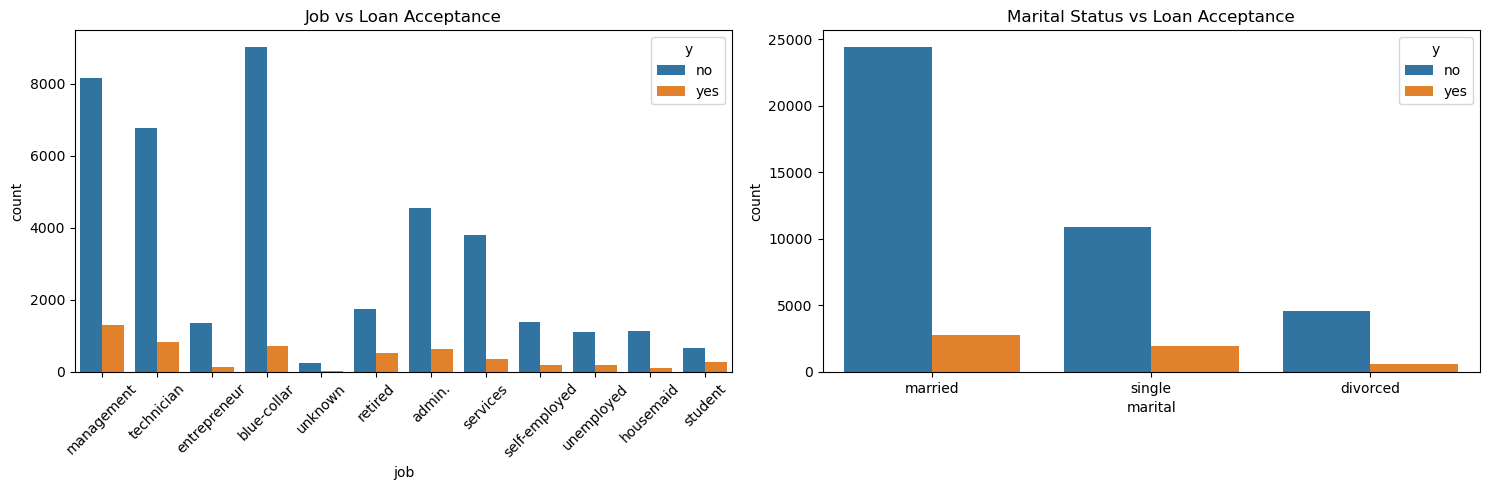

Model Accuracy: 89.35%

--- Detailed Performance ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043


--- Top Influencers ---
     Feature  Importance
11  duration    0.578134
15  poutcome    0.144215
10     month    0.113463


In [14]:
# 2. EXPLORATION
# Let's look at how 'Job' and 'Marital Status' affect the outcome
plt.figure(figsize=(15, 5))

# Plot A: Job vs Acceptance
plt.subplot(1, 2, 1)
sns.countplot( data=df, x='job', hue='y',)
plt.title('Job vs Loan Acceptance')
plt.xticks(rotation=45)

# Plot B: Marital Status vs Acceptance
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='marital', hue='y', )
plt.title('Marital Status vs Loan Acceptance')

plt.tight_layout()
plt.show()

# 3. PREPROCESSING
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 4. SPLIT THE DATA
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAIN THE MODEL
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 6. RESULTS
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\n--- Detailed Performance ---")
print(classification_report(y_test, y_pred))

# 7. BUSINESS INSIGHT 
# This tells us which factors actually mattered most to the model
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print("\n--- Top Influencers ---")
print(importance.sort_values(by='Importance', ascending=False).head(3))